# Evaluating the genre model

Step 3 of training. This scores the served model (`models/genre_classifier.keras`) on the
600 test photos, which played no part in training or in choosing the model, and answers three questions:

1. Does the network beat simple baselines?
2. Which genres does it get wrong, and what does it confuse them with?
3. How good could any model be, given how consistent the labels themselves are?

Run it top to bottom after `build_dataset.py` and `train.py`.

In [1]:
import csv

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, cohen_kappa_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from data_files import DATA_DIR, MODEL_PATH, load_labels, load_split
from genres import GENRES

x_train, y_train = load_split("train")
x_test, y_test = load_split("test")
predicted = tf.keras.models.load_model(MODEL_PATH).predict(x_test, verbose=0).argmax(axis=1)

## 1. Accuracy against baselines

Top-1 accuracy: how often the model's first choice matches the label.

- **Most common genre:** always guess the genre with the most training photos. Any useful model must beat this.
- **Logistic regression:** a linear model on the same 8 features. If the network only matches it,
  the features, not the model, are what limit accuracy.

In [2]:
most_common = np.full_like(y_test, np.bincount(y_train).argmax())
logistic = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(x_train, y_train)

for name, guesses in {
    "Most common genre": most_common,
    "Logistic regression": logistic.predict(x_test),
    "Neural network (served)": predicted,
}.items():
    print(f"{name:24s} {accuracy_score(y_test, guesses):.1%}")

Most common genre        35.7%
Logistic regression      76.3%
Neural network (served)  77.3%


## 2. Per genre

Precision: when the model says a genre, how often it is right. Recall: of the photos with that label,
how many the model finds. Support is the number of test photos with that label.

In [3]:
print(classification_report(y_test, predicted, target_names=GENRES, digits=3, zero_division=0))

              precision    recall  f1-score   support

   EDM_CHILL      0.764     0.737     0.750       114
    EDM_DROP      0.871     0.651     0.745        83
   RETROWAVE      0.500     0.100     0.167        10
   CINEMATIC      0.758     0.850     0.802       214
       HOUSE      0.769     0.799     0.784       179

    accuracy                          0.773       600
   macro avg      0.732     0.627     0.649       600
weighted avg      0.774     0.773     0.768       600



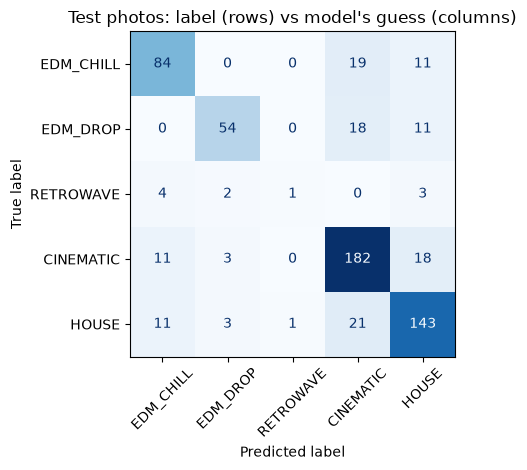

In [4]:
ConfusionMatrixDisplay.from_predictions(y_test, predicted, display_labels=GENRES,
                                        xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Test photos: label (rows) vs model's guess (columns)")
plt.tight_layout()
plt.show()

## 3. How consistent are the labels?

150 random photos were labeled a second time by a different labeler, using the same guide and without
seeing the first labels (`data/second_labels.csv`). How often two labelers agree is a practical ceiling:
a model cannot be expected to match the labels much more often than the labelers match each other.
Cohen's kappa corrects the agreement for chance (0 means chance, 1 means perfect).

In [5]:
labels = load_labels()
with (DATA_DIR / "second_labels.csv").open(newline="") as file:
    second = {row["image"]: row["genre"] for row in csv.DictReader(file)}

first_labels = [labels[image] for image in second]
second_labels = list(second.values())
print(f"{len(second)} photos labeled twice: the labelers agree on "
      f"{accuracy_score(first_labels, second_labels):.1%}, Cohen's kappa {cohen_kappa_score(first_labels, second_labels):.2f}")

150 photos labeled twice: the labelers agree on 74.7%, Cohen's kappa 0.64


## Conclusions

- **The model learned real patterns.** 77.3% of test photos get the labeled genre, against 35.7% for
  always guessing the most common genre.
- **The features set the limit, not the model.** Logistic regression on the same 8 numbers reaches 76.3%,
  one point behind. The network is kept because it is slightly better and still tiny (about 5,000 weights).
- **The labels set a ceiling near here.** Two labelers agree on 74.7% of photos (kappa 0.64, "substantial"
  agreement on the Landis and Koch scale), and the model matches the labels about as often. More tuning
  on these labels cannot buy much; richer features (colour per image region, or a pretrained image
  embedding) or sharper genre definitions would.
- **Most mistakes involve CINEMATIC**, the muted middle of the mood range: chill, drop and house photos
  are each guessed as cinematic about 20 times. Opposite moods are never confused: no EDM_CHILL photo is
  called EDM_DROP, or the reverse.
- **RETROWAVE is the weak spot.** Only 47 of the 3,000 everyday photos (1.6%) have its neon or magenta
  look, 10 of them in the test set, and the model finds 1. Class weights were tried in `train.py` and cost
  4 points of overall accuracy for one extra hit. Users can still choose Retrowave themselves.